# Практикум №6. Реконструкцiя i породження зображень на основi глибоких моделей автокодувальникiв

0. Імпорт залежностей.

In [1]:
import random
import numpy as np
import torch
import torchvision.datasets as datasets

from torch import nn
from torch import optim

from sklearn.datasets import make_blobs
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from src.util.torch_device import resolve_torch_device, to_numpy
from src.visualization.plot import (
    plot_2d_data,
    plot_3d_data,
    plot_1d_data,
    sample_random_images,
    plot_tensors,
)
from src.model.auto_encoder import (
    AutoEncoder,
    NoiseCancelingAutoEncoder,
    HashEncoder,
    ConvHashEncoder,
)
from src.trainer.auto_encoder_trainer import AutoEncoderTrainer
from src.definitions import EXTERNAL_DATA_FOLDER
from src.util.noise import add_noise, guassian_noise
from src.trainer.simple_trainer import SimpleTrainer
from src.model.noisy_mnist import NoisyMnist
from src.trainer.vae_trainer import VaeTrainer
from src.model.vae import VAE
from src.trainer.hash_encoder_trainer import HashEncoderTrainer
from src.util.collection import list_to_index_dict

random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)
rng = np.random.RandomState(random_seed)
device = resolve_torch_device()

1. Виконати зниження розмiрностi даних за допомогою автокодувальника:

i. Згенерувати (самостiйно) точки у тривимiрному просторi. Розбити їх на навчальний i тестовий набори.

In [2]:
points_count = 100_000

points, _ = make_blobs(
    n_samples=points_count,
    centers=5,
    n_features=3,
    cluster_std=1.0,
    random_state=random_seed,
)

train_size = int(points_count * 0.8)

points_train = torch.tensor(points[:train_size], dtype=torch.float32).to(device)
points_test = torch.tensor(points[train_size:], dtype=torch.float32).to(device)
points = torch.tensor(points, dtype=torch.float32).to(device)

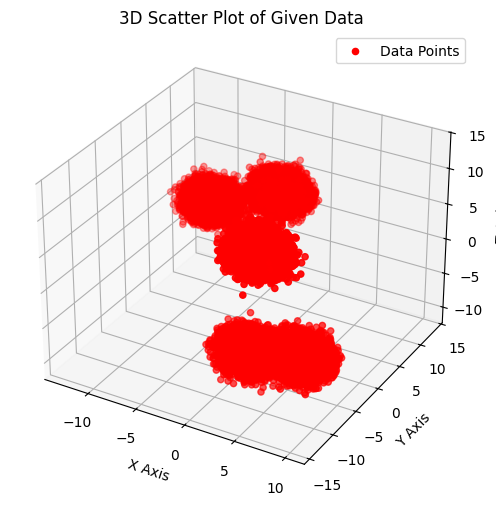

In [3]:
plot_3d_data(to_numpy(points))

ii. Побудувати двi моделi лiнiйного автокодувальника: одну - для двовимiрного, iншу - для одновимiрного представлення.

In [4]:
two_dim_autoencoder = AutoEncoder([3, 512, 2]).to(device)
one_dim_autoencoder = AutoEncoder([3, 512, 1]).to(device)

iii. Навчити моделi на навчальних даних.

In [5]:
criterion = nn.MSELoss().to(device)
optimizer = optim.Adam(two_dim_autoencoder.parameters(), lr=1e-3)
trainer = AutoEncoderTrainer(
    two_dim_autoencoder,
    criterion,
    200,
    optimizer,
)

trainer.train(points_train)

  0%|          | 0/200 [00:00<?, ?it/s]

In [6]:
_, decoded = two_dim_autoencoder(points_test)

mean_squared_error(to_numpy(points_test), to_numpy(decoded))

2.4262888

In [7]:
criterion = nn.MSELoss().to(device)
optimizer = optim.Adam(one_dim_autoencoder.parameters(), lr=1e-3)
trainer = AutoEncoderTrainer(
    one_dim_autoencoder,
    criterion,
    200,
    optimizer,
)

trainer.train(points_train)

  0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
_, decoded = one_dim_autoencoder(points_test)

mean_squared_error(to_numpy(points_test), to_numpy(decoded))

14.730048

iv. Отримати двовимiрне представлення тестового набору даних. Вiдобразити це двовимiрне представлення графiчно.

In [9]:
encoded, _ = two_dim_autoencoder(points)

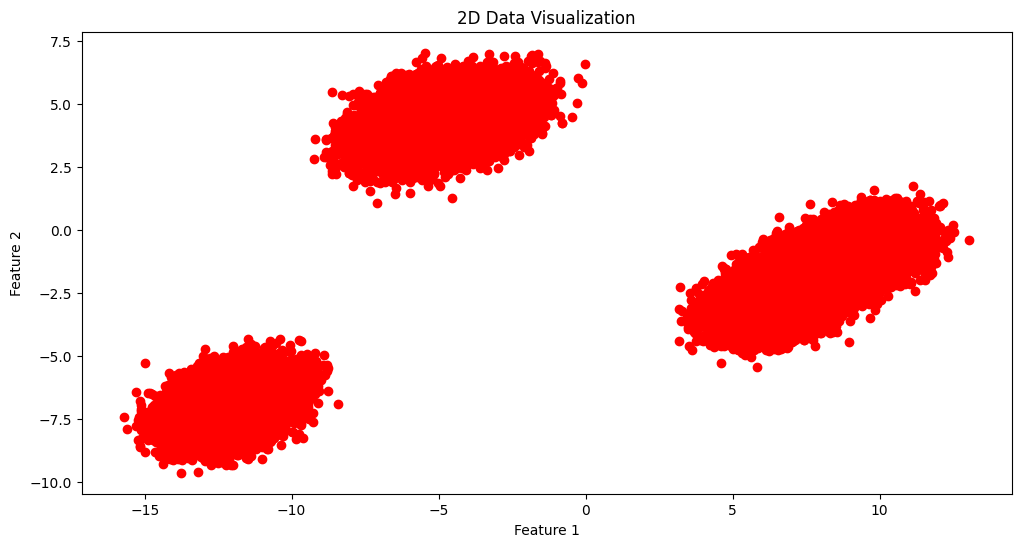

In [10]:
plot_2d_data(to_numpy(encoded))

v. Отримати одновимiрне представлення тестового набору даних. Вiдобразити одновимiрне представлення графiчно.

In [11]:
encoded, _ = one_dim_autoencoder(points)

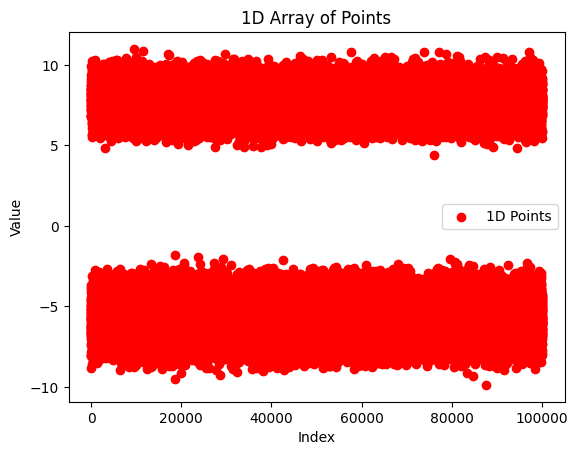

In [12]:
plot_1d_data(to_numpy(encoded))

vi. Аналогiчно побудувати i навчити двi моделi нелiнiйного автокодувальника. Яким є прирiст ефективностi порiвняно з лiнiйними моделями?

In [13]:
two_dim_autoencoder = AutoEncoder(
    [3, 512, 512, 512, 512, 512, 2], activation="relu"
).to(device)
one_dim_autoencoder = AutoEncoder(
    [3, 512, 512, 512, 512, 512, 1], activation="relu"
).to(device)

In [14]:
criterion = nn.MSELoss().to(device)
optimizer = optim.Adam(two_dim_autoencoder.parameters(), lr=1e-3)
trainer = AutoEncoderTrainer(
    two_dim_autoencoder,
    criterion,
    200,
    optimizer,
)

trainer.train(points_train)

  0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
_, decoded = two_dim_autoencoder(points_test)

mean_squared_error(to_numpy(points_test), to_numpy(decoded))

0.58300537

In [16]:
criterion = nn.MSELoss().to(device)
optimizer = optim.Adam(one_dim_autoencoder.parameters(), lr=1e-3)
trainer = AutoEncoderTrainer(
    one_dim_autoencoder,
    criterion,
    200,
    optimizer,
)

trainer.train(points_train)

  0%|          | 0/200 [00:00<?, ?it/s]

In [17]:
_, decoded = one_dim_autoencoder(points_test)

mean_squared_error(to_numpy(points_test), to_numpy(decoded))

0.6854332

In [18]:
encoded, _ = two_dim_autoencoder(points)

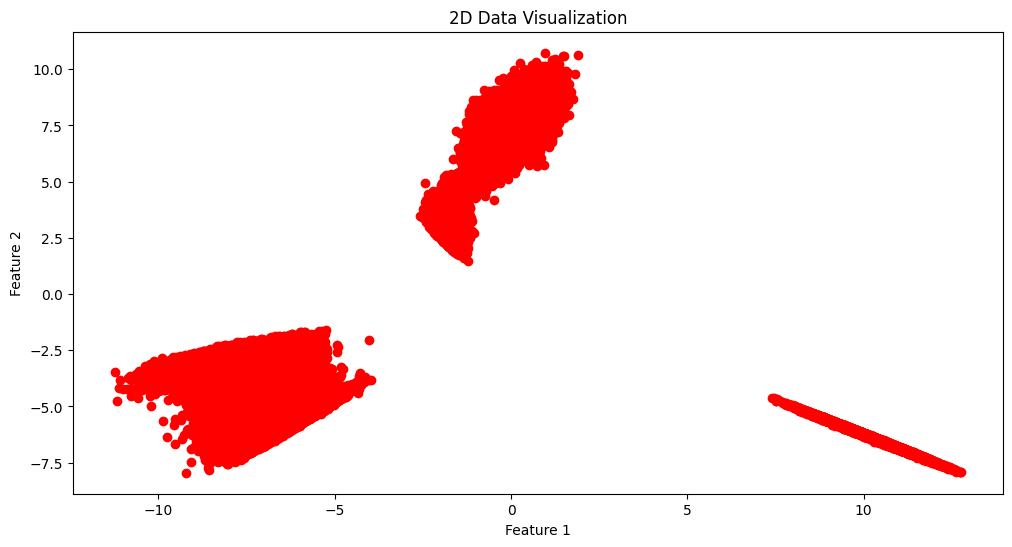

In [19]:
plot_2d_data(to_numpy(encoded))

In [20]:
encoded, _ = one_dim_autoencoder(points)

In [21]:
encoded.shape

torch.Size([100000, 1])

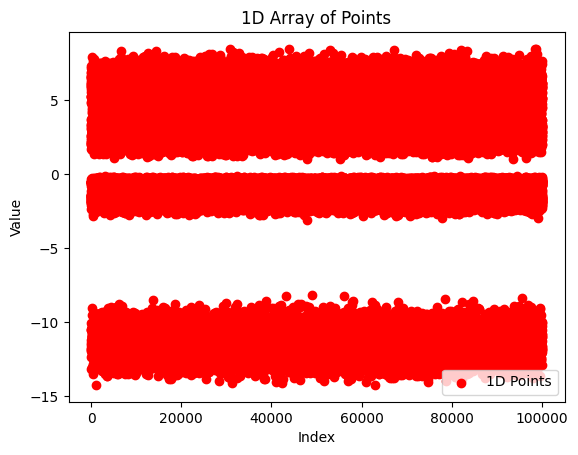

In [22]:
plot_1d_data(to_numpy(encoded))

2. Побудувати глибокi моделi шумопригнiчуючого i регуляризованого автокодувальника для реконструкцiї зображень.

3. Виконати попереднє навчання класифiкатора зображень, використовуючи шумопригнiчуючий автокодувальник:

i. Завантажити обраний набiр даних iз зображеннями.

In [23]:
mnist = datasets.MNIST(root=EXTERNAL_DATA_FOLDER, train=True, download=True)

x = np.array(mnist.data)
y = np.array(mnist.targets)

x = x.astype(np.float32) / 255.0

ii. Розбити данi на три пiдмножини: навчальну; валiдацiйну - для налаштування значень гiперпараметрiв; тестову - для остаточної оцiнки якостi.

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=random_seed
)

guassian_noise_x_train = np.array([guassian_noise(it) for it in x_train])
x_noise_train = np.array([add_noise(it) for it in x_train])
x_noise_test = np.array([add_noise(it) for it in x_test])

In [25]:
guassian_noise_x_train = torch.tensor(
    guassian_noise_x_train, dtype=torch.float32, device=device
)[:, None, :, :]
x_noise_train = torch.tensor(x_noise_train, dtype=torch.float32, device=device)[
    :, None, :, :
]
x_noise_test = torch.tensor(x_noise_test, dtype=torch.float32, device=device)[
    :, None, :, :
]

x_train = torch.tensor(x_train, dtype=torch.float32, device=device)[:, None, :, :]
x_test = torch.tensor(x_test, dtype=torch.float32, device=device)[:, None, :, :]

y_train = torch.tensor(y_train, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test, dtype=torch.float32, device=device)

iii. Побудувати глибоку модель шумопригнiчуючого автокодувальника. Навчити її на навчальному наборi.

In [26]:
autoencoder = NoiseCancelingAutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
trainer = SimpleTrainer(
    autoencoder,
    criterion,
    500,
    optimizer,
)

trainer.train(x_noise_train, x_train)

  0%|          | 0/500 [00:00<?, ?it/s]

iv. Спробувати пiдiбрати гiперпараметри моделi, використовуючи перехресну перевiрку, так щоб модель гарно виконувала реконструкцiю зображень.

v. Випадково обрати кiлька зображень iз тестової множини, надрукувати їх разом з їх реконструкцiями.

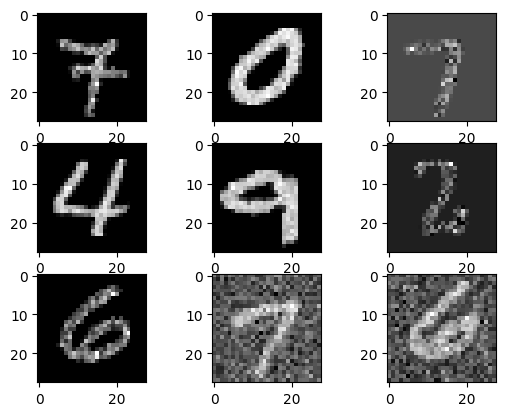

In [27]:
random_x = sample_random_images(x_noise_train.cpu())

plot_tensors(random_x)

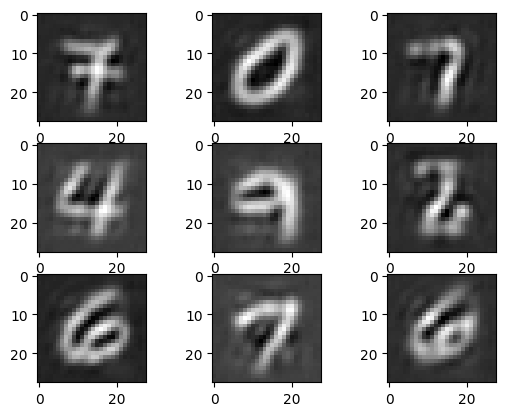

In [28]:
noiseless_x = autoencoder(torch.stack(random_x).to(device))

plot_tensors(noiseless_x.cpu().detach())

vi. Надрукувати знайденi низькорiвневi ознаки зображень.

vii. Вiдобразити зображення, якi бiльше нiж iншi активують кожен нейрон в кодуючому шарi.

viii. Використати найнижчi шари побудованої моделi шумопригнiчуючого автокодувальника:

* На їх основi побудувати глибоку нейронну мережу для класифiкацiї.

In [29]:
mnist_model = NoisyMnist(autoencoder, num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mnist_model.parameters(), lr=1e-3)
trainer = SimpleTrainer(
    mnist_model,
    criterion,
    500,
    optimizer,
)

* Навчити цю модель, використовуючи 10% навчального набору.

In [30]:
train_count = x_noise_train.shape[0]
new_train_count = int(train_count * 0.1)
x_noise_train = x_noise_train[:new_train_count]
y_train = y_train[:new_train_count]

In [31]:
trainer.train(x_noise_train, y_train)

  0%|          | 0/500 [00:00<?, ?it/s]

In [32]:
_, y_pred = torch.max(mnist_model(x_noise_test), 1)

In [33]:
accuracy_score(y_test.cpu().detach().numpy(), y_pred.cpu().detach().numpy())

0.91625

* Чи може ця модель працювати так само добре як аналогiчна модель, навчена на повному навчальному наборi?

4. Сгенерувати новi зображення, використовуючи варiацiйний автокодувальник:

i. Побудувати модель варiацiйного автокодувальника. Функцiю втрат визначити як суму втрати реконструкцiї та латентної втрати.

ii. Обрати цiкавий набiр даних iз зображеннями.

* Навчити варiацiйний автокодувальник на цьому наборi. Спробувати пiдiбрати значення гiперпараметрiв моделi.

In [34]:
latent_dim = 20
vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-2)
trainer = VaeTrainer(
    vae,
    500,
    optimizer,
)

trainer.train(x_train)

  0%|          | 0/500 [00:00<?, ?it/s]

* Сгенерувати новi зображення, схожi на тi, що є у навчальному наборi.

In [35]:
z = torch.randn(9, latent_dim).to(device)
generated_images = vae.decode(z).cpu().view(-1, 1, 28, 28)

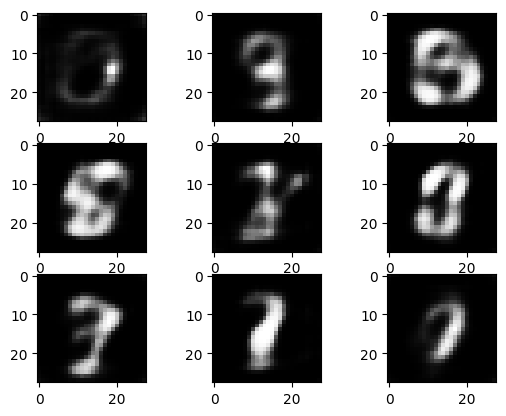

In [36]:
plot_tensors(generated_images.cpu().detach())

iii. Обрати набiр нерозмiчених даних:

* Навчити варiацiйний автокодувальник на цьому наборi. Спробувати пiдiбрати значення гiперпараметрiв моделi.

* Сгенерувати новi зображення, схожi на тi, що є у навчальному наборi.

5. Виконати семантичне хешування зображень iз застосуванням модифiкованого глибокого автокодувальника:

i. Створити першу модель глибокого автокодувальника, яка мiстить два скритих шари i наступний за ними кодуючий скритий шар. Розглянути декiлька варiантiв кодувальних шарiв з 20, 30 i 40 нейронами (iншою кiлькiстю?) i логiстичною функцiєю активацiї.

In [37]:
x_hash_train = x_train.reshape((x_train.shape[0], -1))
x_hash_test = x_test.reshape((x_test.shape[0], -1))

In [38]:
hash_encoder = HashEncoder([784, 20, 30, 40]).to(device)
optimizer = optim.Adam(hash_encoder.parameters(), lr=1e-3)
trainer = HashEncoderTrainer(
    hash_encoder,
    200,
    optimizer,
)

ii. Навчити першу модель на обраному наборi зображень.

In [39]:
trainer.train(x_hash_train)

  0%|          | 0/200 [00:00<?, ?it/s]

iii. Отримати хеш деякого зображення пiсля навчання:

* прогнати зображення через автокодувальник,

In [40]:
y_hash_pred, _ = hash_encoder(x_hash_test)

* взяти вихiд кодуючого шару i округлити кожне це вихiдне значення до найближчого цiлого числа: 0 або 1.

In [41]:
y_hash_pred = (
    torch.where(y_hash_pred > 0, torch.tensor(1), torch.tensor(0))
    .cpu()
    .detach()
    .numpy()
    .astype(int)
)

In [42]:
y_hash_pred = ["".join(map(str, it)) for it in y_hash_pred]

In [43]:
len(list_to_index_dict(y_hash_pred))

4

iv. Створити другу модель шляхом додавання гаусiвського шуму з нульовим середнiм до входiв кодуючого шару першої моделi тiльки пiд час навчання. Для того щоб вiдношення сигналу до шуму зберiгалося високим, автокоду вальник буде вчитися надавати великi значення кодуючому шару i таким чином шум стає незначним. Тому логiстична функцiя кодуючого шару, скорiш за все, буде насичуватися в точцi 0 або 1.

In [45]:
guassian_noise_x_train = guassian_noise_x_train.reshape((x_train.shape[0], -1))

v. Навчити другу модель на тому ж наборi зображень. Отримати хеш всiх зображень пiсля навчання, виконавши дiї, аналогiчнi пункту вище. Скорiш за все, округлення вихiдних значень кодуючого шару до 0 або 1 не дуже сильно спотворить кодування. Це пiдвищить надiйнiсть хешiв. Додатково:

In [46]:
hash_encoder = HashEncoder([784, 20, 30, 40]).to(device)
optimizer = optim.Adam(hash_encoder.parameters(), lr=1e-3)
trainer = HashEncoderTrainer(
    hash_encoder,
    200,
    optimizer,
)

trainer.train(guassian_noise_x_train)

  0%|          | 0/200 [00:00<?, ?it/s]

* Вiдобразити зображення, якi мають однаковi хешi. Вiзуально оцiнити чи виглядають однаковими зображення, що мають однаковi хешi. Набори зображень є розмiченими, тому бiльш об’єктивний спосiб вимiрювання ефективностi автокодувальника для семантичного хешування полягає в тому, щоб перевiрити, чи будуть зображення з тим самим хешем мати один i той самий клас.

In [47]:
y_hash_pred, _ = hash_encoder(x_hash_test)

In [48]:
y_hash_pred = (
    torch.where(y_hash_pred > 0, torch.tensor(1), torch.tensor(0))
    .cpu()
    .detach()
    .numpy()
    .astype(int)
)

In [49]:
y_hash_pred = ["".join(map(str, it)) for it in y_hash_pred]

In [50]:
len(list_to_index_dict(y_hash_pred))

8

* Перевiрити, чи будуть зображення з тим самим хешем мати один i той самий клас. Розрахувати середнє значення iндексiв забрудненостi Джинi наборiв зображень з однаковими або дуже схожими хешами. Це середнє значення можна вважати оцiнкою ефективностi автокодувальника для семантичного хешування.

* Спробувати налаштувати гiперпараметри моделi.

vi. Розглянути третю модель - глибоку згорткову мережу для класифiкацiї. Використати вихiдний шар цiєї моделi для отримання хешiв.

In [51]:
hash_encoder = ConvHashEncoder().to(device)
optimizer = optim.Adam(hash_encoder.parameters(), lr=1e-3)
trainer = HashEncoderTrainer(
    hash_encoder,
    200,
    optimizer,
)

trainer.train(x_train)

  0%|          | 0/200 [00:00<?, ?it/s]

In [52]:
y_hash_pred, _ = hash_encoder(x_train)

In [53]:
y_hash_pred = (
    torch.where(y_hash_pred > 0, torch.tensor(1), torch.tensor(0))
    .cpu()
    .detach()
    .numpy()
    .astype(int)
)

In [54]:
y_hash_pred = ["".join(map(str, it)) for it in y_hash_pred]

In [55]:
len(list_to_index_dict(y_hash_pred))

45304

vii. Порiвняти результати, отриманi трьома моделями.